In [13]:
import scanpy as sc
import pandas as pd

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

In [15]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()
adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 16148
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id'
    obsm: 'spatial'

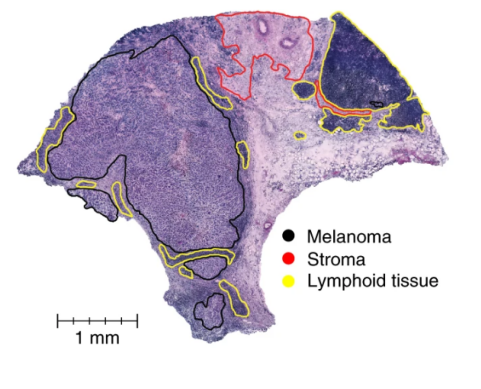

In [16]:
img = mpimg.imread("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/melanoma_rep1.png")

plt.imshow(img)
plt.axis("off")   # hides axes
plt.show()

In [17]:
K=5

In [18]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4,V5
7x15,0.153972,3.379900e-01,0.356935,0.120388,0.030715
7x16,0.241165,2.635902e-01,0.259546,0.157340,0.078360
7x17,0.439378,6.204702e-02,0.043830,0.261143,0.193603
7x18,0.098241,1.600677e-01,0.101100,0.163460,0.477131
8x13,0.226912,1.116450e-01,0.405918,0.227123,0.028401
...,...,...,...,...,...
27x18,0.091942,4.697952e-03,0.083208,0.356231,0.463921
27x19,0.044722,1.713644e-03,0.177189,0.282192,0.494183
27x20,0.180331,1.179278e-04,0.023703,0.502040,0.293808
27x21,0.571735,1.102414e-06,0.007096,0.364151,0.057017


In [19]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

In [20]:
snmf_signatures = pd.read_csv(f"./K{K}/SNMF/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4,V5
PSME2,4.447504e+00,2.301499e+00,1.573209e+01,6.860616,2.597574
CUEDC1,3.027134e-01,7.238853e-01,4.602129e-01,0.015874,0.645284
RPLP1,9.025826e+01,6.242096e+01,2.868254e+01,63.621973,233.241011
TM9SF3,1.559318e+00,1.729010e+00,1.670180e+00,2.173441,0.518193
DEF8,1.622941e+00,1.465461e+00,1.119922e+00,1.364098,2.298179
...,...,...,...,...,...
MICU3,2.747248e-01,5.198973e-20,0.000000e+00,0.000000,0.466426
CTAGE5,3.191667e-01,3.814920e-02,8.802337e-21,0.000000,0.220406
ALPL,2.129374e-01,0.000000e+00,0.000000e+00,0.426286,0.000000
GPC3,9.023129e-21,0.000000e+00,0.000000e+00,0.829798,0.000000


In [21]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

In [22]:
SIGNATURES = {
    "Tumor cells": ["CD63","PMEL","ATP1A1","S100A1","SPP1"],
    "Fibroblasts": ["COL1A1","COL1A2"],
    "B cells": ["CD19", "MS4A1"],
    "T cells": ["CD2","CD3D","CD3E","CD3G","CD7"],
    "Macrophages": ["CD14","FCGR1A","FCGR1B"],
}

In [23]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V2    Tumor cells
V4    Fibroblasts
V3    Macrophages
V1        B cells
V5      ambiguous
dtype: object


In [24]:
N_TOP_GENES = 10

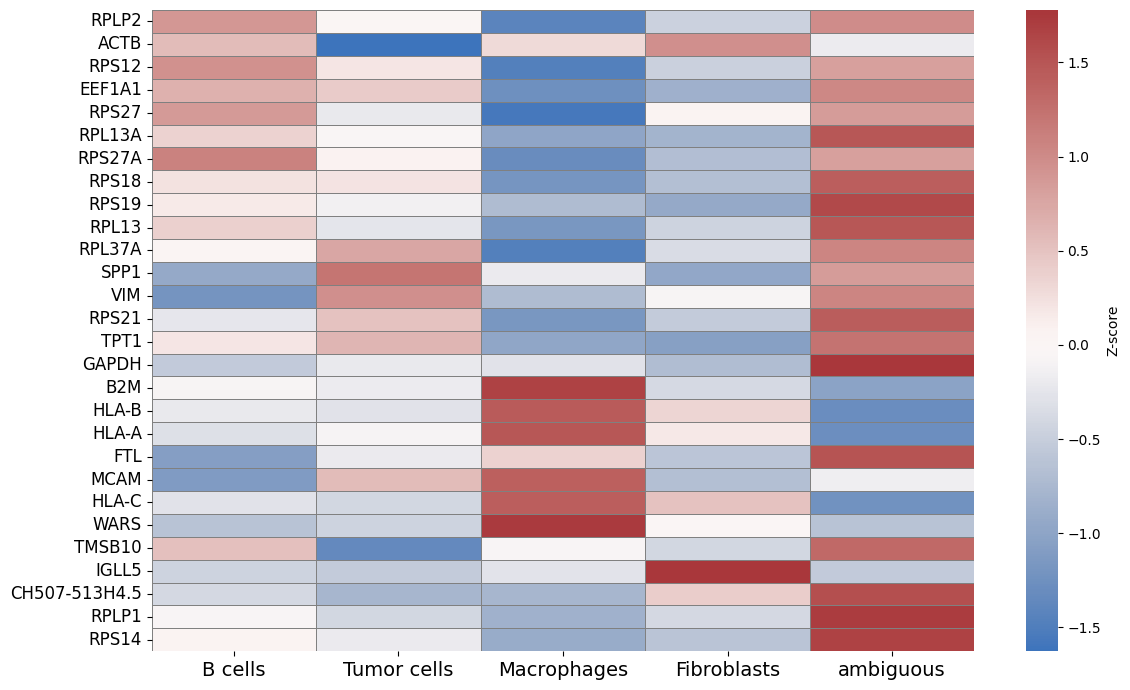

In [25]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

B cells variance: 0.10540489402292058
B cells range: 0.920169415310617
B cells mean: 0.6126729957942914

Tumor cells variance: 0.18914825309958577
Tumor cells range: 1.4213888170334577
Tumor cells mean: 0.46998912211113736

Macrophages variance: 0.6016524570637801
Macrophages range: 2.0164047542608525
Macrophages mean: 0.9440225166477099

Fibroblasts variance: 0.48105429386989407
Fibroblasts range: 2.2414481153731574
Fibroblasts mean: 0.24194889660569013

ambiguous variance: 0.047632172775136865
ambiguous range: 0.7670468435638307
ambiguous mean: 1.512180350999587



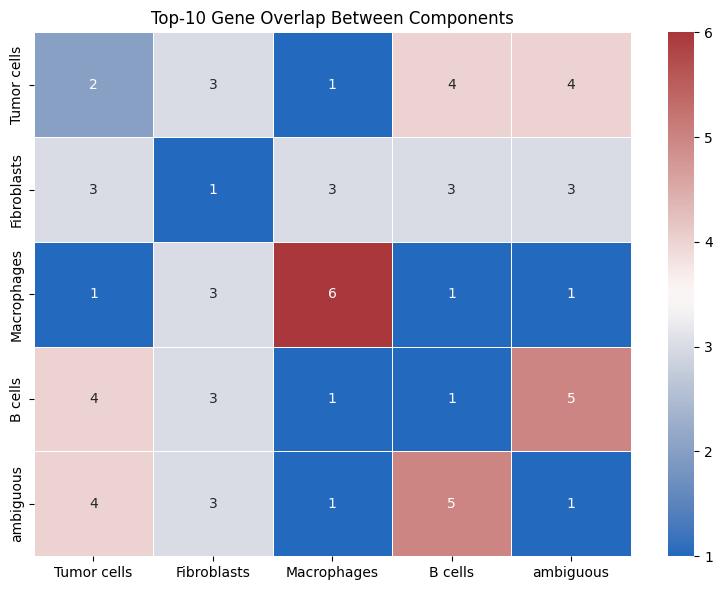

In [27]:
# ----- 1️⃣ Get top genes per component -----
n_top_genes=220

top_dict = {
    annotation[comp]: set(
        snmf_signatures[comp]
        .sort_values(ascending=False)
        .head(N_TOP_GENES)
        .index
    )
    for comp in snmf_signatures.columns
}

components = annotation.values.tolist()

# ----- 2️⃣ Build intersection matrix -----
overlap_matrix = pd.DataFrame(
    0,
    index=components,
    columns=components
)

for c1 in components:
    for c2 in components:
        if c1 == c2:
            rest_genes = set().union(*[top_dict[c] for c in components if c != c1])
            overlap_matrix.loc[c1, c2] = len(
                top_dict[c1] - rest_genes
            )
        else:
            overlap_matrix.loc[c1, c2] = len(
                top_dict[c1].intersection(top_dict[c2])
            )

# ----- 3️⃣ Plot heatmap -----
plt.figure(figsize=(8, 6))

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt="d",
    cmap="vlag",
    linewidths=0.5
)

plt.title(f"Top-{N_TOP_GENES} Gene Overlap Between Components")
plt.tight_layout()
plt.show()

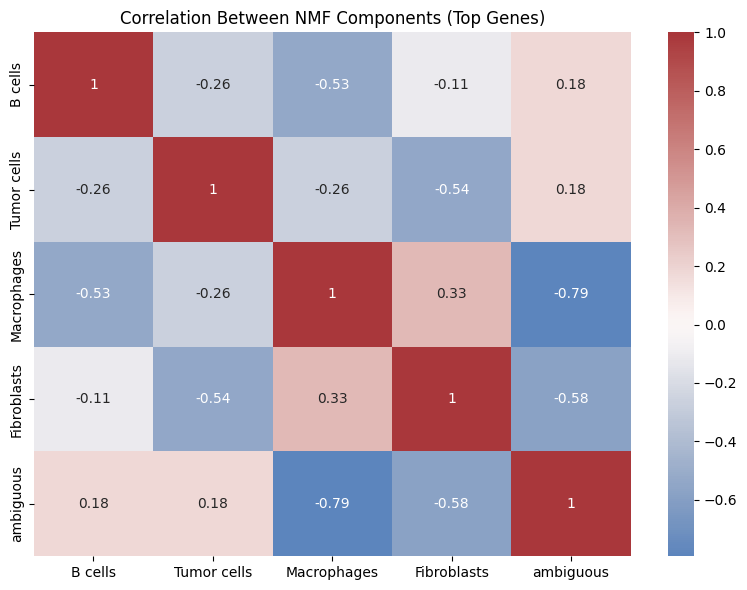

In [28]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between NMF Components (Top Genes)")

plt.tight_layout()
plt.show()

In [29]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

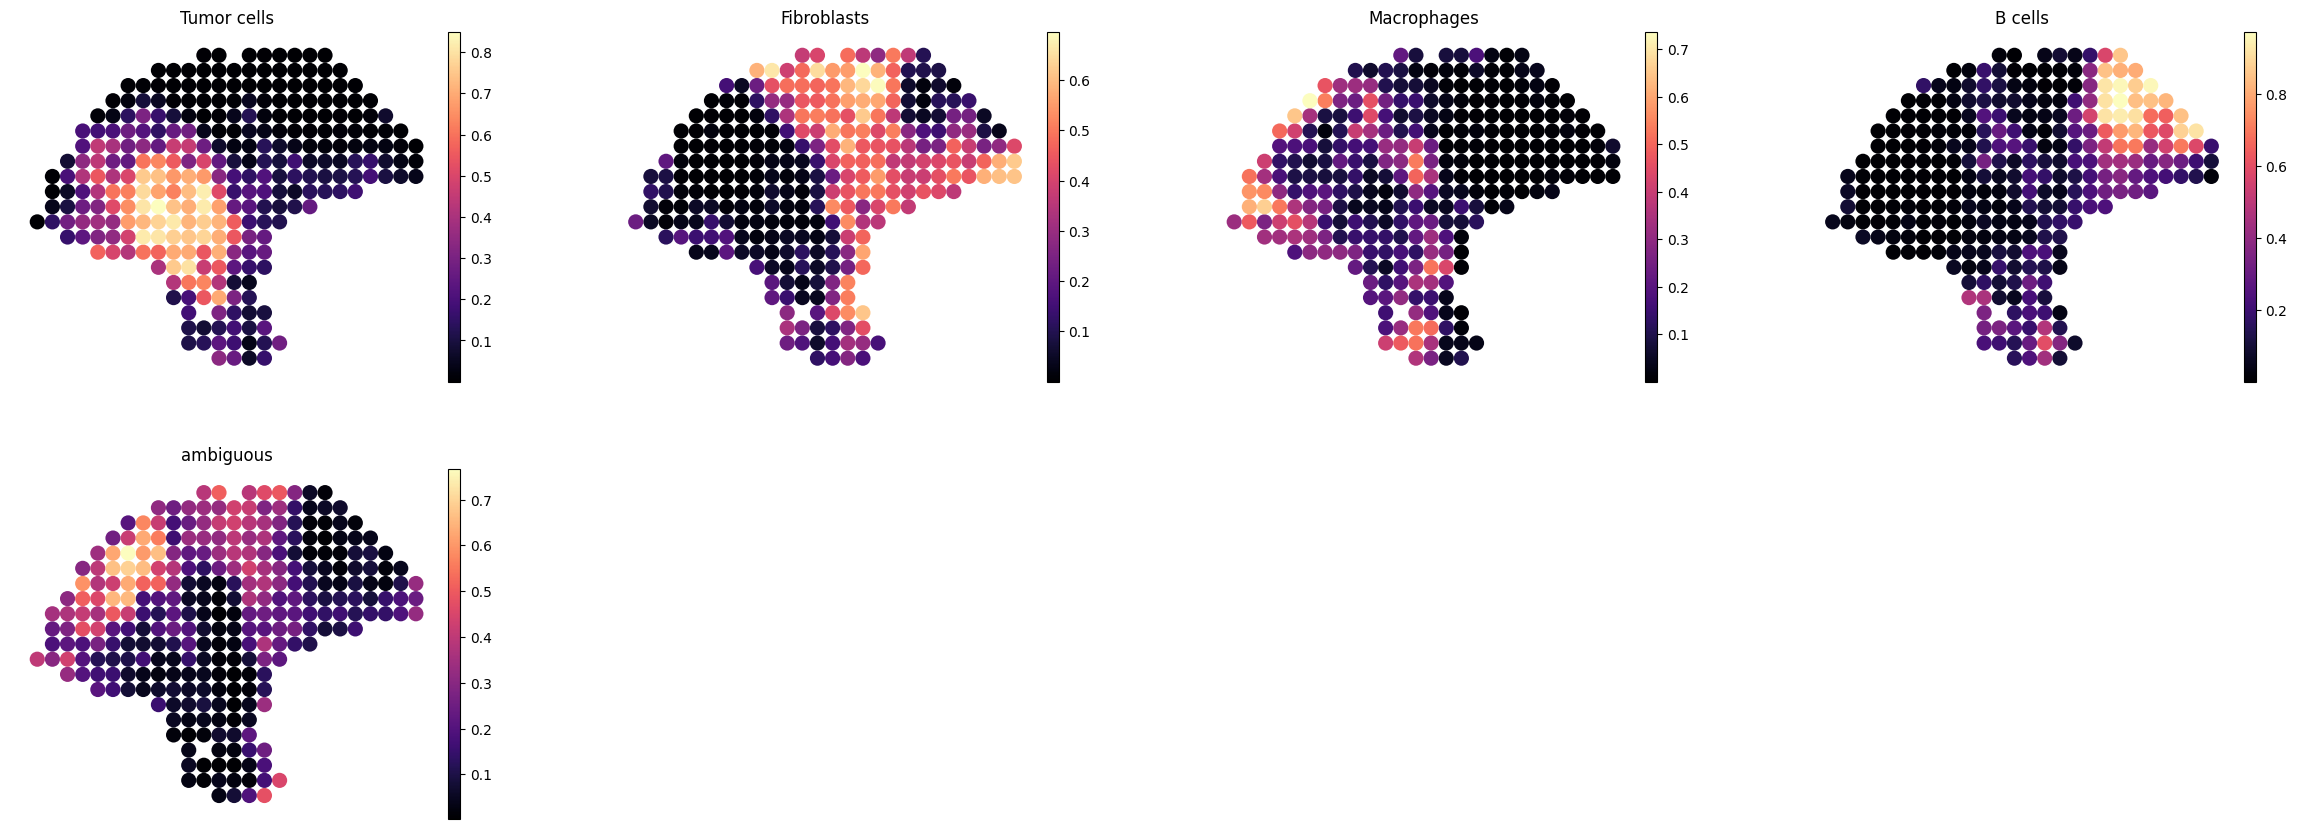

In [44]:
sc.pl.spatial(adata, color=annotation.unique().tolist(), spot_size=1, frameon=False, cmap='magma')

In [31]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

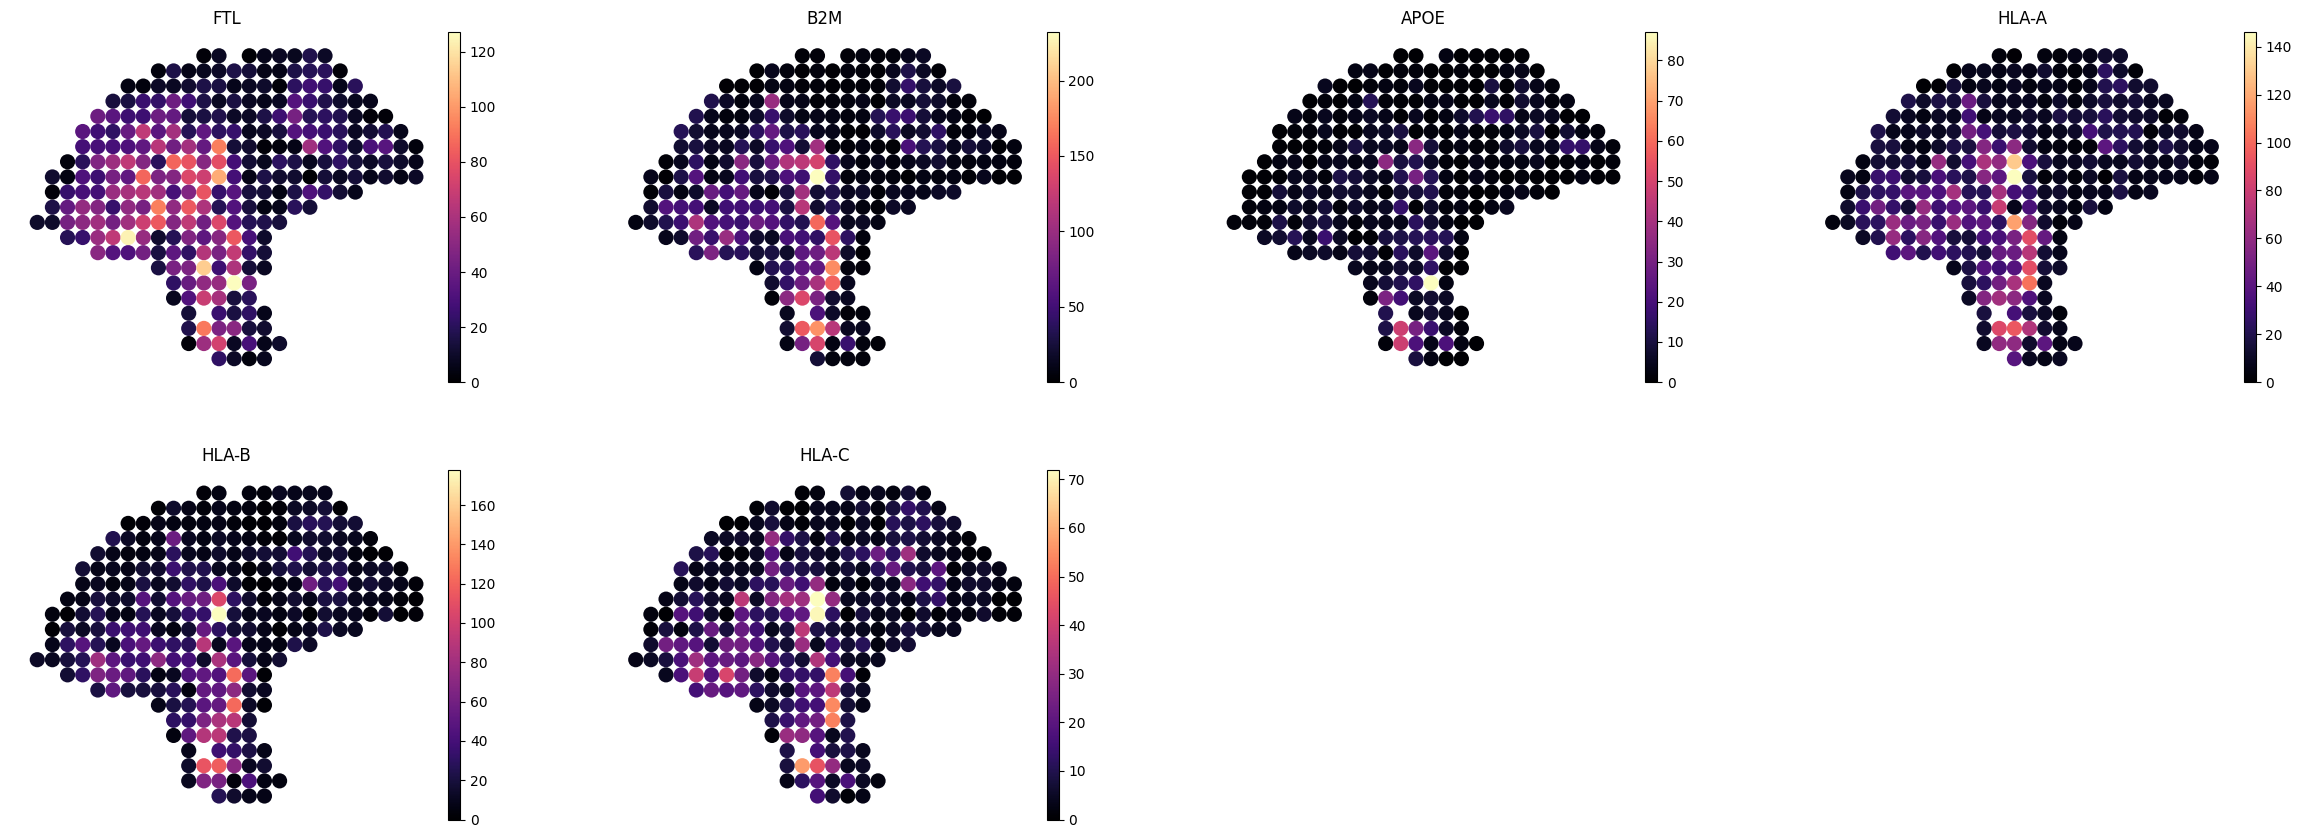

In [39]:
sc.pl.spatial(adata, color=TRANSITION_AREA_EXPRESSED_GENES, spot_size=1, frameon=False, cmap='magma')

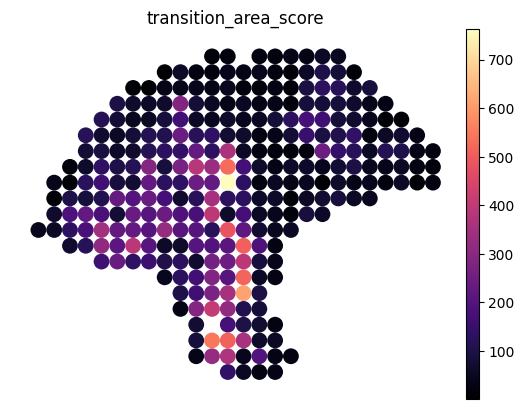

In [43]:
adata.obs["transition_area_score"] = adata[:,TRANSITION_AREA_EXPRESSED_GENES].X.sum(axis=1)
sc.pl.spatial(adata, color="transition_area_score", spot_size=1, frameon=False, cmap='magma')

In [48]:
adata.obs.loc[~adata.obs["is_in_transition_area"],"is_in_transition_area"]

7x15     False
7x16     False
7x17     False
7x18     False
8x13     False
         ...  
27x18    False
27x19    False
27x20    False
27x21    False
27x22    False
Name: is_in_transition_area, Length: 237, dtype: bool

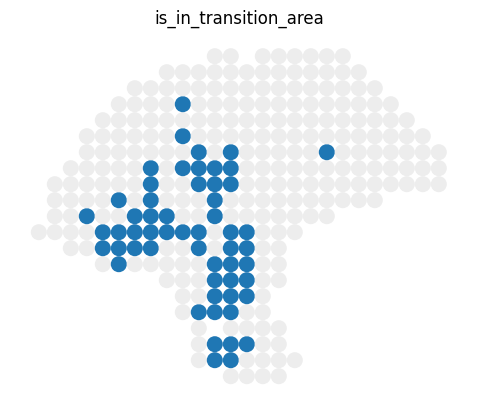

In [56]:
transition_score_threshold = 200
adata.obs["is_in_transition_area"] = np.where(
    adata.obs["transition_area_score"] > transition_score_threshold,
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

sc.pl.spatial(
    adata,
    color="is_in_transition_area",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none"
)

In [35]:
from scipy.stats import spearmanr

for component in ["Fibroblasts","Macrophages"]:
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"],component].values, adata.obs.loc[adata.obs["is_in_transition_area"],"transition_area_score"].values)
    print(f"Spearman correlation between {component} component and transition area: {rho:.4f} (pval {pval:.4f})")

from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"],"entropy"].values, adata.obs.loc[adata.obs["is_in_transition_area"],"transition_area_score"].values)
print(f"\nSpearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between Fibroblasts component and transition area: 0.3826 (pval 0.0036)
Spearman correlation between Macrophages component and transition area: 0.4993 (pval 0.0001)

Spearman correlation between proportions entropy and transition area: 0.3722 (pval 0.0047)
